In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy.stats import gaussian_kde

import utils

In [2]:
data_dir = '/Users/rebekahzhang/data/behavior_data'
exp = "exp2"
data_folder = os.path.join(data_dir, exp)

figure_folder = os.path.join(data_dir, f'{exp}_figures')
os.makedirs(figure_folder, exist_ok=True)

In [3]:
# two_colors = plt.cm.viridis(np.linspace(0, 1, 2))
two_colors = ["#ffb400", "#9080ff"]
custom_palette = {'s': two_colors[0], 'l': two_colors[1]}

In [4]:
sessions_training = pd.read_csv(os.path.join(data_folder, f'sessions_cleaned.csv'))
trials_training_filtered2 = pd.read_csv(os.path.join(data_folder, 'trials_cleaned.csv'))

In [5]:
mice_s = trials_training_filtered2[trials_training_filtered2['group'] == 's']['mouse'].unique()
mice_l = trials_training_filtered2[trials_training_filtered2['group'] == 'l']['mouse'].unique()

s_colors = plt.cm.twilight(np.linspace(0, 1, len(mice_s)))
l_colors = plt.cm.twilight_shifted(np.linspace(0, 1, len(mice_l)))
s_mouse_palette = dict(zip(mice_s, s_colors))
l_mouse_palette = dict(zip(mice_l, l_colors))
mouse_palette = {**s_mouse_palette, **l_mouse_palette}

# LMEM

In [6]:
# --- coding & centering ---
lmem_data = trials_training_filtered2.copy()
lmem_data['group_numeric'] = (lmem_data['group'] == 'l').astype(int)
session_mean = lmem_data['session'].mean()
trial_mean   = lmem_data['session_trial_num'].mean()

# scale session by 10 to help convergence
lmem_data['session_c'] = (lmem_data['session'] - session_mean) / 10.0
lmem_data['trial_c']   = lmem_data['session_trial_num'] - trial_mean

# --- fit: fixed = group × (session_c + session_c^2) + trial_c; random = intercept + session_c
model = smf.mixedlm(
    "time_waited ~ group_numeric * session_c + group_numeric * I(session_c**2) + trial_c",
    data=lmem_data,
    groups=lmem_data["mouse"],
    re_formula="~session_c"
)
result = model.fit(method="lbfgs")
print(result.summary())

                  Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      time_waited  
No. Observations:      593721       Method:                  REML         
No. Groups:            31           Scale:                   50.9257      
Min. group size:       6280         Log-Likelihood:          -2009467.6839
Max. group size:       32754        Converged:               Yes          
Mean group size:       19152.3                                            
--------------------------------------------------------------------------
                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                        1.894    0.473  4.002 0.000  0.967  2.822
group_numeric                    2.711    0.639  4.242 0.000  1.458  3.964
session_c                       -0.161    0.561 -0.286 0.775 -1.260  0.939
group_numeric:session_c         -0.032    0.

/Users/rebekahzhang/opt/anaconda3/envs/LUCKYCHARM/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [7]:
# --- prediction grid at mean trial (trial_c=0) ---
sessions_raw = np.linspace(lmem_data['session'].min(), lmem_data['session'].max(), 200)
sessions_c   = (sessions_raw - session_mean) / 10.0
groups = ['l', 's']

pred_df = pd.DataFrame({
    'session_raw': np.tile(sessions_raw, 2),
    'session_c':   np.tile(sessions_c, 2),
    'group':       np.repeat(groups, len(sessions_raw)),
    'trial_c':     0.0,  # predict at mean trial
    'mouse':       lmem_data['mouse'].iloc[0],
})
pred_df['group_numeric'] = (pred_df['group'] == 'l').astype(int)
pred_df['pred_time'] = result.predict(pred_df)

# --- empirical mean ± SE by session × group ---
session_stats = (
    lmem_data
    .groupby(['session', 'group'], as_index=False)
    .agg(
        mean_tw=('time_waited', 'mean'),
        std_tw =('time_waited', 'std'),
        count  =('time_waited', 'count')
    )
)
session_stats['se_tw'] = session_stats['std_tw'] / np.sqrt(session_stats['count'].clip(lower=1))

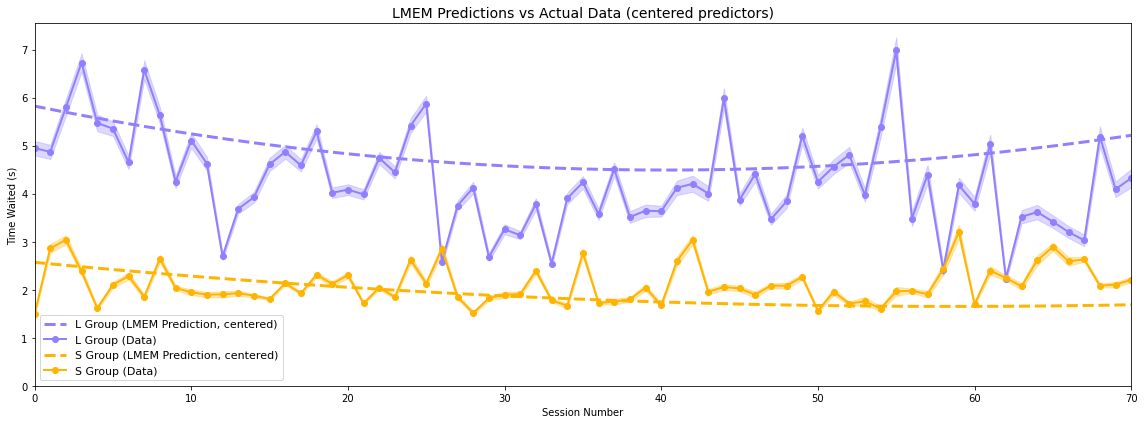

In [8]:
plt.figure(figsize=(16, 6))
for g in groups:
    sel = pred_df['group'] == g
    plt.plot(
        pred_df.loc[sel, 'session_raw'],
        pred_df.loc[sel, 'pred_time'],
        '--', linewidth=3, color=custom_palette[g],
        label=f'{g.upper()} Group (LMEM Prediction, centered)'
    )
    gd = session_stats[session_stats['group'] == g]
    plt.plot(
        gd['session'], gd['mean_tw'],
        'o-', markersize=6, linewidth=2, color=custom_palette[g],
        label=f'{g.upper()} Group (Data)'
    )
    plt.fill_between(
        gd['session'],
        gd['mean_tw'] - gd['se_tw'],
        gd['mean_tw'] + gd['se_tw'],
        alpha=0.3, color=custom_palette[g]
    )

plt.title('LMEM Predictions vs Actual Data (centered predictors)', fontsize=14)
plt.xlabel('Session Number'); plt.ylabel('Time Waited (s)')
plt.legend(fontsize=11); plt.xlim(lmem_data['session'].min(), lmem_data['session'].max())
plt.ylim(bottom=0); plt.tight_layout()
plt.savefig(f'{figure_folder}/predictions_centered.png', dpi=300, bbox_inches='tight')

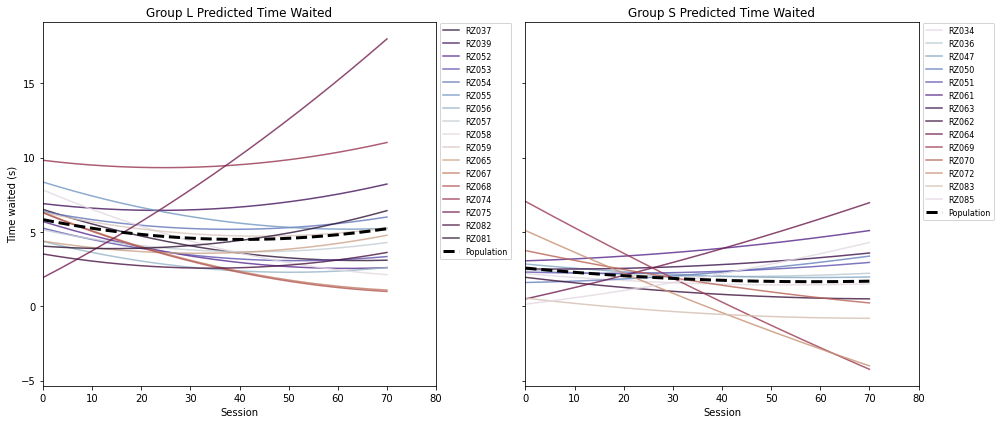

In [9]:
# Simplified: population line is black, legend moved to right, code streamlined

def get_u0_u1(u):
    # Extract random intercept and slope for a mouse
    u0 = u.get('Intercept', u.get('const', u.get('Group', u.iloc[0] if hasattr(u, "iloc") else 0.0)))
    u1 = u.get('session_c', 0.0)
    return float(u0), float(u1)

fe = result.params
def fe_predict(session_c, group_numeric, trial_c=0.0):
    return (
        fe['Intercept']
        + fe.get('group_numeric', 0.0) * group_numeric
        + fe.get('session_c', 0.0) * session_c
        + fe.get('group_numeric:session_c', 0.0) * group_numeric * session_c
        + fe.get('I(session_c ** 2)', 0.0) * (session_c ** 2)
        + fe.get('group_numeric:I(session_c ** 2)', 0.0) * group_numeric * (session_c ** 2)
        + fe.get('trial_c', 0.0) * trial_c
    )

session_mean = lmem_data['session'].mean()
sessions_raw = np.linspace(lmem_data['session'].min(), lmem_data['session'].max(), 200)
sessions_c = (sessions_raw - session_mean) / 10.0

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
group_list = ['l', 's']

for i, g in enumerate(group_list):
    ax = axes[i]
    gn = 1 if g == 'l' else 0

    # Plot each mouse's fitted curve
    mice = lmem_data.loc[lmem_data['group'] == g, 'mouse'].unique()
    for m in mice:
        u = result.random_effects.get(m)
        if u is None:
            continue
        u0, u1 = get_u0_u1(u)
        y_mouse = fe_predict(sessions_c, gn) + u0 + u1 * sessions_c
        color = mouse_palette.get(m, "#888888")
        ax.plot(sessions_raw, y_mouse, color=color, alpha=0.8, linewidth=1.5, label=m)

    # Overlay population curve in black
    y_pop = fe_predict(sessions_c, gn)
    ax.plot(sessions_raw, y_pop, '--', color='black', linewidth=3, label='Population')

    ax.set_title(f"Group {g.upper()} Predicted Time Waited")
    ax.set_xlabel('Session')
    if i == 0:
        ax.set_ylabel('Time waited (s)')
    ax.set_xlim(0, 80)
    # Legend to the right of each subplot
    ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1.01))

plt.tight_layout()
plt.savefig(f'{figure_folder}/predictions_centered_by_group.png', dpi=300, bbox_inches='tight')

                           term       est        lo       hi         pval
                  group_numeric  2.711363  1.458465 3.964260 2.220230e-05
                      Intercept  1.894312  0.966591 2.822033 6.279707e-05
group_numeric:I(session_c ** 2)  0.055293  0.042617 0.067968 1.232516e-17
              I(session_c ** 2)  0.026694  0.017465 0.035924 1.439309e-08
                        trial_c  0.004797  0.004675 0.004919 0.000000e+00
          Group x session_c Cov -0.002997       NaN      NaN          NaN
        group_numeric:session_c -0.032233 -1.517200 1.452735 9.660657e-01
                      session_c -0.160617 -1.260268 0.939034 7.746664e-01


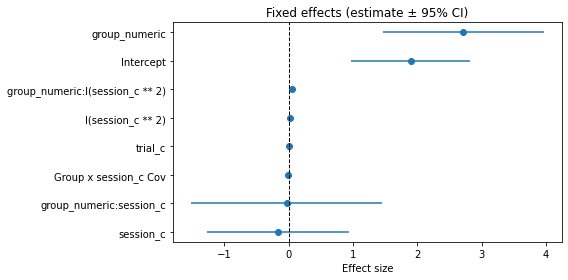

In [10]:
ci = result.conf_int()
coef = result.params
coef_df = pd.DataFrame({
    'term': coef.index,
    'est': coef.values,
    'lo': ci[0].values,
    'hi': ci[1].values,
    'pval': result.pvalues.values
})

fixed_mask = ~coef_df['term'].str.contains('^Group Var|^session_c Var|^Intercept Var|^Cov|^Scale', regex=True)
coef_df = coef_df[fixed_mask]

print(coef_df.sort_values('est', ascending=False).to_string(index=False))

coef_df = coef_df.sort_values('est')
plt.figure(figsize=(8, max(4, 0.5*len(coef_df))))
plt.hlines(y=coef_df['term'], xmin=coef_df['lo'], xmax=coef_df['hi'])
plt.plot(coef_df['est'], coef_df['term'], 'o')
plt.axvline(0, color='k', linewidth=1, linestyle='--')
plt.title('Fixed effects (estimate ± 95% CI)')
plt.xlabel('Effect size'); plt.tight_layout()
plt.savefig(f'{figure_folder}/fixed_effects_ci.png', dpi=300, bbox_inches='tight')

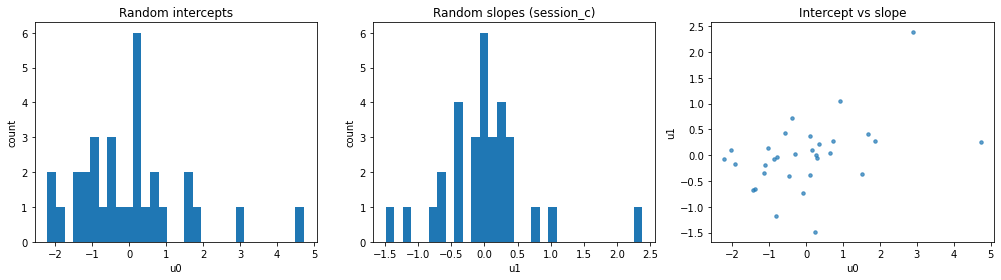

In [11]:
re_list = []
for m, u in result.random_effects.items():
    u0, u1 = (u.get('Intercept', u.get('const', u.get('Group', u.iloc[0]))),
              u.get('session_c', 0.0))
    re_list.append({'mouse': m, 'u0_intercept': float(u0), 'u1_session_c': float(u1)})
re_df = pd.DataFrame(re_list)

plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
plt.hist(re_df['u0_intercept'], bins=30)
plt.title('Random intercepts'); plt.xlabel('u0'); plt.ylabel('count')

plt.subplot(1,3,2)
plt.hist(re_df['u1_session_c'], bins=30)
plt.title('Random slopes (session_c)'); plt.xlabel('u1'); plt.ylabel('count')

plt.subplot(1,3,3)
plt.scatter(re_df['u0_intercept'], re_df['u1_session_c'], s=12, alpha=0.7)
plt.title('Intercept vs slope'); plt.xlabel('u0'); plt.ylabel('u1')
plt.tight_layout()

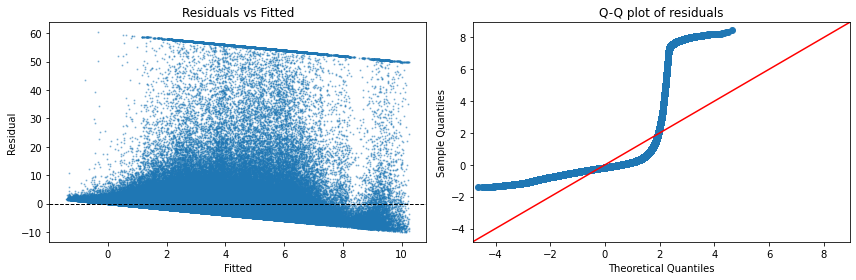

In [12]:
resid = result.resid
fitted = result.fittedvalues

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Residuals vs Fitted
ax1.scatter(fitted, resid, s=1, alpha=0.4)
ax1.axhline(0, color='k', linestyle='--', linewidth=1)
ax1.set_xlabel('Fitted')
ax1.set_ylabel('Residual')
ax1.set_title('Residuals vs Fitted')

# Q-Q plot for residuals
sm.qqplot(resid, line='45', fit=True, ax=ax2)
ax2.set_title('Q-Q plot of residuals')

plt.tight_layout()